# Zeitreihenanalyse

In diesem Notebook werden verschiedene Zeitreihendatensätze analysiert und miteinander verglichen. Ziel der Analyse ist es, zeitliche Muster, Trends, saisonale Effekte sowie statistische Eigenschaften der Daten zu untersuchen.

Dazu werden drei unterschiedliche Datensätze betrachtet:
- Gold Price Dataset (Goldpreise)
- Apple Stock Dataset (Aktienkurse)
- Weather Dataset (Temperaturdaten)

Die Analyse umfasst die Datenbereinigung, explorative Visualisierung, deskriptive Statistik sowie die Untersuchung zeitlicher Abhängigkeiten mithilfe von Zeitreihenmethoden wie ACF, Stationaritätsanalyse sowie AR-, MA-, ARMA- und ARIMA-Modellen.

## 1. Bibliotheken importieren

Für die Analyse werden Bibliotheken zur Datenverarbeitung, Visualisierung und Modellierung verwendet.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

## 2. Datensätze laden

Die Datensätze für Amazon Sales, Apple Stock und Wetterdaten werden eingelesen und anschließend überprüft.

In [75]:
gold = pd.read_csv("data/raw/GoldPrice.csv", low_memory=False)
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")


## 3. Überblick über die Datensätze

Zur ersten Orientierung werden die Dimensionen und die ersten Zeilen der Datensätze angezeigt.

In [76]:
datasets = {
    "Gold Price": gold,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)

Gold Price
(2531, 6)


,Date,Price,Open,High,Low,Chg%
0,"Sep 11, 2020",1957.35,1952.55,1963.3,1944.35,-0.0035
1,"Sep 10, 2020",1964.30,1955.30,1975.2,1948.60,0.0048
2,"Sep 09, 2020",1954.90,1939.40,1959.7,1926.30,0.0060
3,"Sep 08, 2020",1943.20,1938.00,1948.3,1911.70,0.0031
4,"Sep 07, 2020",1937.10,1940.70,1947.4,1930.45,-0.0018


Apple Stock
(2596, 6)


,Price,Close,High,Low,Open,Volume
0,2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
1,2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2,2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
3,2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
4,2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# 4. Zeitreihenanalyse

### Stil setzen

In [77]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Goldpreis im Zeitverlauf

Der wöchentliche Goldpreis zeigt über den gesamten Zeitraum einen langfristigen Aufwärtstrend. Besonders ab 2019 steigt der Goldpreis deutlich an. Kurzfristige Schwankungen sind weiterhin sichtbar, insgesamt entwickelt sich die Zeitreihe jedoch relativ stabil. Die Wochenaggregation reduziert tägliches Rauschen und macht den langfristigen Trend besser erkennbar.

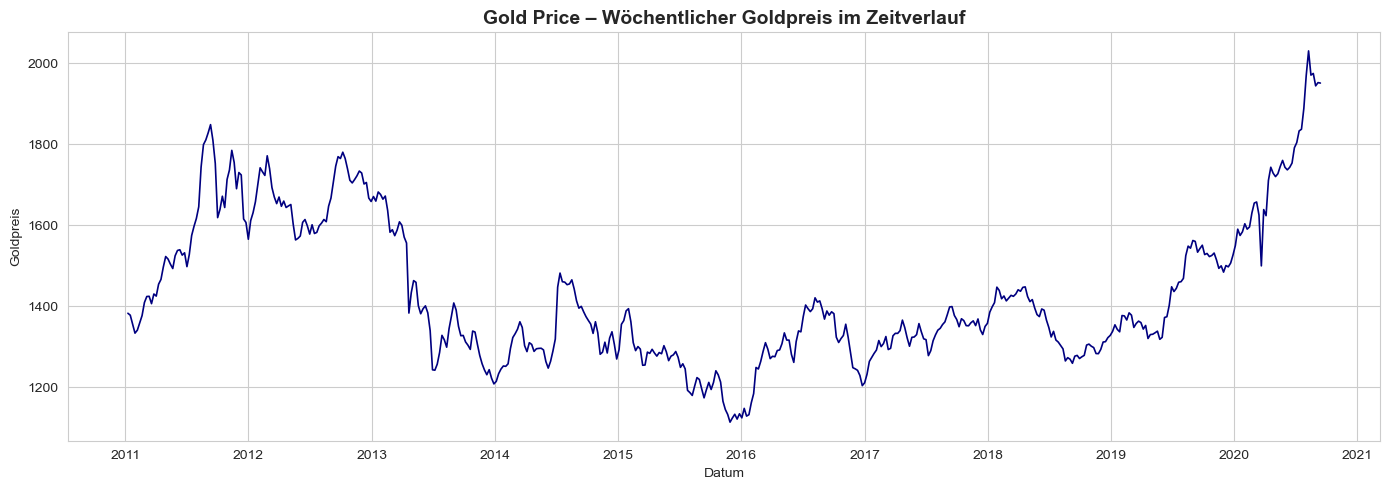

In [78]:
# Gold Price Datensatz vorbereiten
df_gold = datasets["Gold Price"].copy()

# Datum konvertieren
df_gold["Date"] = pd.to_datetime(df_gold["Date"])

# Nach Datum sortieren
df_gold = df_gold.sort_values("Date")

# Preis als numerischen Wert umwandeln
df_gold["Price"] = pd.to_numeric(df_gold["Price"], errors="coerce")

# Fehlende Werte entfernen
df_gold = df_gold.dropna(subset=["Price"])

# Wöchentliche Durchschnittspreise berechnen
gold_weekly = (
    df_gold
    .set_index("Date")["Price"]
    .resample("W")
    .mean()
)

# Plot
fig, ax = plt.subplots()

ax.plot(
    gold_weekly.index,
    gold_weekly.values,
    color="navy",
    linewidth=1.2
)

ax.set_title(
    "Gold Price – Wöchentlicher Goldpreis im Zeitverlauf",
    fontsize=14,
    weight="bold"
)

ax.set_ylabel("Goldpreis")
ax.set_xlabel("Datum")

plt.tight_layout()
plt.show()

## Erkenntnisse – Goldpreis im Zeitverlauf

Monatlich aggregierter Gesamtumsatz als Heatmap. Zeigt auf einen Blick ob saisonale Muster (z.B. Q4) oder jahresspezifische Ausreißer existieren.

# Apple Stock

## Kursentwicklung (Close Price)

AAPL hat sich von ~$30 (2016) auf ~$260 (2026) mehr als verachtfacht. Markante Einbrüche: COVID-Crash (März 2020) und Zinsanstieg-Korrektur (2022). Ab 2023 starke Erholung mit neuem Allzeithoch ~$275 Ende 2024.

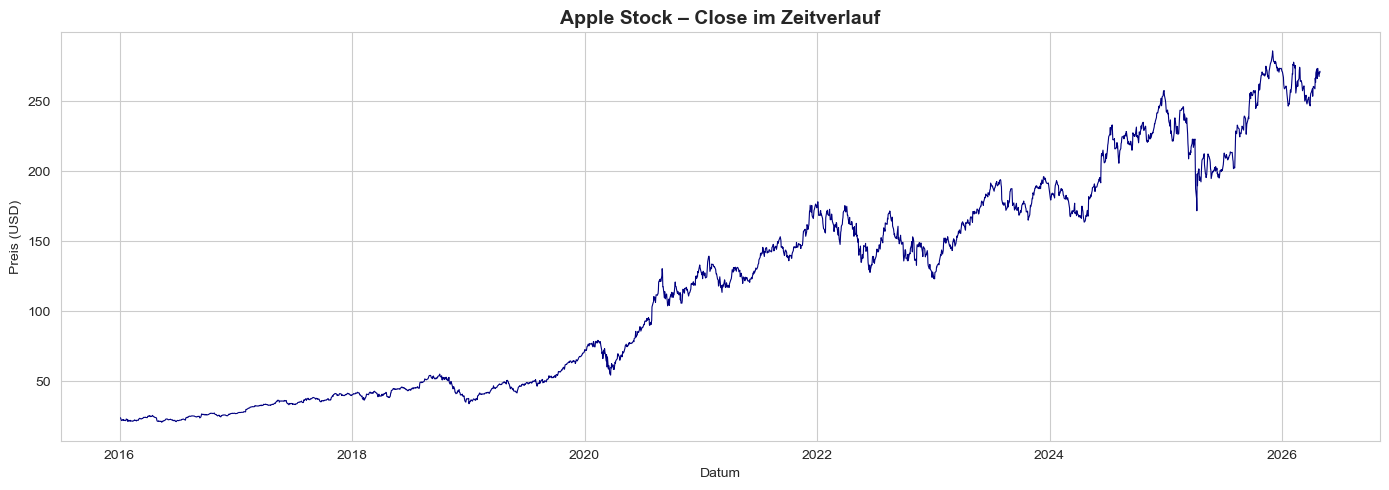

In [79]:
df_apple = datasets["Apple Stock"].copy()
df_apple["Price"] = pd.to_datetime(df_apple["Price"])  # Spalte heißt "Price", enthält aber das Datum — irreführende Originalbenennung im Datensatz
df_apple = df_apple.rename(columns={"Price": "Date"}).set_index("Date")

fig, ax = plt.subplots()
ax.plot(df_apple.index, df_apple["Close"], color="navy", linewidth=0.8)
ax.set_title("Apple Stock – Close im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Preis (USD)")
ax.set_xlabel("Datum")

plt.tight_layout()
plt.show()

# Weather 

## Temperaturverlauf (2009–2017)

Klare Saisonalität mit Sommermaxima ~20–35°C und Winterminima bis –20°C. Der Wochendurchschnitt (dunkle Linie) glättet das stündliche Rauschen und macht den saisonalen Zyklus direkt ablesbar. Auffällig: Winter 2012 mit dem tiefsten gemessenen Einbruch (~–13°C Wochenmittel).

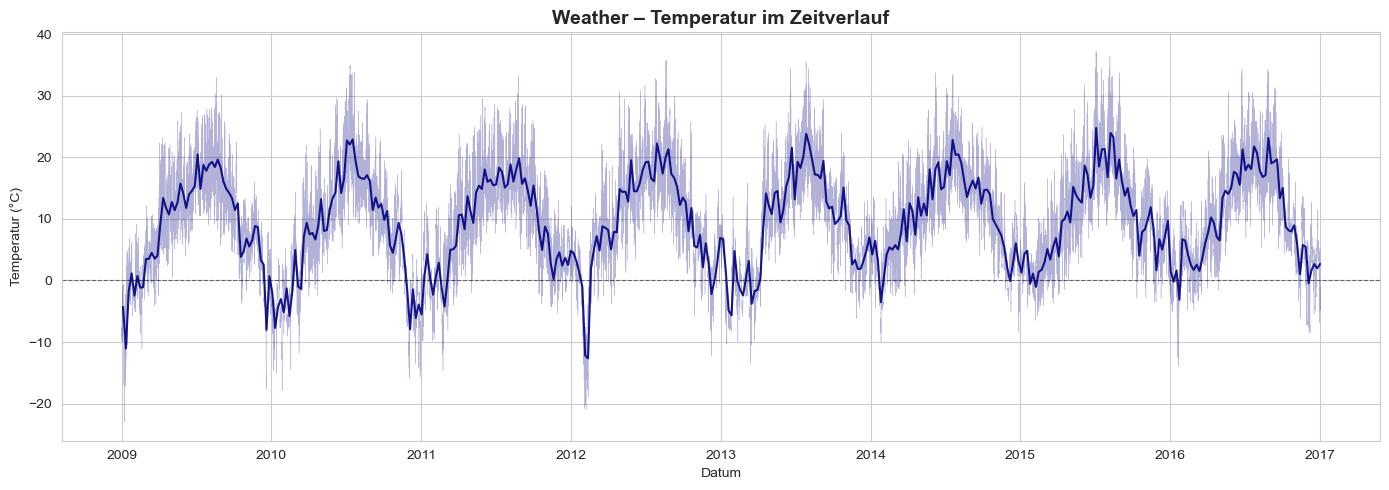

In [81]:
weather_index = pd.to_datetime(datasets["Weather"]["Date Time"], format="%d.%m.%Y %H:%M:%S")

df_temp_weekly = (
    datasets["Weather"]
    .set_index(weather_index)["T (degC)"]
    .resample("W")
    .mean()
)

fig, ax = plt.subplots()
ax.plot(weather_index, datasets["Weather"]["T (degC)"],
        color="navy", linewidth=0.3, alpha=0.3)
ax.plot(df_temp_weekly.index, df_temp_weekly.values,
        color="navy", linewidth=1.5, alpha=0.9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Weather – Temperatur im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

# 5. Datenaufbereitung

### Hilfsfunktion: Ausreißer entfernen (IQR-Methode)

Die Funktion wird für alle drei Datensätze wiederverwendet. Ein Wert gilt als Ausreißer, wenn er außerhalb von Q1/Q3 ± 1.5 × IQR liegt (Menden, Folie 48).

In [82]:
def remove_outliers_iqr(df, columns):
    mask = pd.Series(True, index=df.index)
    for col in columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        mask &= df[col].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return df[mask]

### Gold – Goldpreise bereinigen

Datum wird als Index gesetzt, fehlende Werte und Duplikate entfernt sowie Ausreißer im Goldpreis über die IQR-Methode bereinigt.

Die Ausreißerbehandlung dient dazu, extreme Einzelwerte und mögliche Mess- oder Eingabefehler zu reduzieren. Bei Finanzzeitreihen können starke Preissprünge jedoch reale Marktbewegungen widerspiegeln. Die Bereinigung wurde daher bewusst vorsichtig durchgeführt.

In [83]:
# Schritt 1: Datum als Index setzen
df_gold["Date"] = pd.to_datetime(df_gold["Date"])
df_gold = df_gold.set_index("Date").sort_index()

# Schritt 2: Fehlende Werte & Duplikate entfernen
df_gold = df_gold.dropna()
df_gold = df_gold.drop_duplicates()

# Schritt 3: Ausreißer im Goldpreis entfernen
df_gold = remove_outliers_iqr(df_gold, ["Price"])

print("Gold bereinigt:", df_gold.shape)

Gold bereinigt: (2496, 5)


### Apple – Aktienkurse bereinigen

Die Datumsspalte ist im Originaldatensatz irreführend als `Price` benannt und wird zunächst umbenannt. Anschließend werden nur die relevanten numerischen Spalten konvertiert, fehlende Werte und Duplikate entfernt, Ausreißer im Schlusskurs bereinigt und die tägliche Wachstumsrate berechnet.

In [84]:
# Schritt 1: Datum als Index setzen 
df_apple = df_apple.sort_index()

# Schritt 2: Relevante Spalten zu numerischen Werten konvertieren
num_cols = ["Close", "Open", "High", "Low", "Volume"]
df_apple[num_cols] = df_apple[num_cols].apply(pd.to_numeric, errors="coerce")

# Schritt 3: Fehlende Werte & Duplikate entfernen
df_apple = df_apple.dropna()
df_apple = df_apple.drop_duplicates()

print("Apple bereinigt:", df_apple.shape)

Apple bereinigt: (2595, 6)


### Weather – Wetterdaten bereinigen

Datum wird mit explizitem Format als Index gesetzt, fehlende Werte und Duplikate entfernt, physikalisch unmögliche Windwerte (Sensor-Fehler) gefiltert sowie Ausreißer in der Temperatur bereinigt.

In [85]:
# Schritt 1: Datum als Index setzen
df_weather = datasets["Weather"].copy()
df_weather["Date Time"] = pd.to_datetime(df_weather["Date Time"], format="%d.%m.%Y %H:%M:%S")
df_weather = df_weather.set_index("Date Time").sort_index()

# Schritt 2: Fehlende Werte & Duplikate entfernen
df_weather = df_weather.dropna()
df_weather = df_weather.drop_duplicates()

# Schritt 3: Physikalisch unmögliche Windwerte entfernen (Sensor-Fehler)
df_weather = df_weather[df_weather["wv (m/s)"] >= 0]
df_weather = df_weather[df_weather["max. wv (m/s)"] >= 0]

# Schritt 4: Ausreißer in der Temperatur entfernen
df_weather = remove_outliers_iqr(df_weather, ["T (degC)"])

print("Weather bereinigt:", df_weather.shape)

Weather bereinigt: (418665, 14)


### Wachstumsraten berechnen

Die täglichen Wachstumsraten werden nach der Formel $g_t = \frac{x_t - x_{t-1}}{x_{t-1}}$ berechnet (Menden, Folie 15/16). Für Apple wurde die Wachstumsrate bereits in der Bereinigung (Schritt 5) ermittelt.

In [ ]:
# Gold: tägliche Goldpreis-Wachstumsrate
gold_growth = df_gold["Price"].pct_change(fill_method=None).rename("gold_growth")

# Apple: Wachstumsrate bereits in Schritt 4 der Bereinigung berechnet (apple["close_growth"])
# Schritt 4: Wachstumsrate des Schlusskurses berechnen
df_apple["close_growth"] = df_apple["Close"].pct_change(fill_method=None)
df_apple = df_apple.dropna()
# Weather: tägliche Durchschnittstemperatur → Wachstumsrate
weather_growth = df_weather["T (degC)"].resample("D").mean().pct_change(fill_method=None).rename("temp_growth")

print("Wachstumsraten berechnet")
print(f"   Gold:     {gold_growth.shape}")
print(f"   Apple:    {df_apple['close_growth'].shape}")
print(f"   Weather:  {weather_growth.shape}")

Wachstumsraten berechnet
   Gold:     (2496,)
   Apple:    (2595,)
   Weather:  (2923,)


### Überblick – Bereinigte Datensätze

Abschließende Kontrolle aller drei bereinigten Datensätze: Shape, Zeitraum und verbleibende NaN-Werte.

In [87]:
datasets_clean = {
    "Gold Price": df_gold,
    "Apple Stock": df_apple,
    "Weather": df_weather,
}

for name, df in datasets_clean.items():
    print(f"{'─' * 45}")
    print(f" {name}")
    print(f"   Shape:    {df.shape}")
    print(f"   Zeitraum: {df.index.min().date()} → {df.index.max().date()}")
    print(f"   NaN:      {df.isnull().sum().sum()}")
    print()

─────────────────────────────────────────────
 Gold Price
   Shape:    (2496, 5)
   Zeitraum: 2011-01-03 → 2020-08-25
   NaN:      0

─────────────────────────────────────────────
 Apple Stock
   Shape:    (2595, 6)
   Zeitraum: 2016-01-05 → 2026-04-30
   NaN:      0

─────────────────────────────────────────────
 Weather
   Shape:    (418665, 14)
   Zeitraum: 2009-01-01 → 2017-01-01
   NaN:      0



# 6. Deskriptive Analyse

Die deskriptive Analyse dient dazu, einen ersten Überblick über die Datensätze zu erhalten. Dabei werden statistische Kennzahlen, die Verteilung der Datensätze sowie Unterschiede zwischen den Wochentagen untersucht.

## Gold Price

Verteilung der Goldpreise, zeitliche Streuung und monatliche Unterschiede als Grundlage für die anschließende Zeitreihenmodellierung.

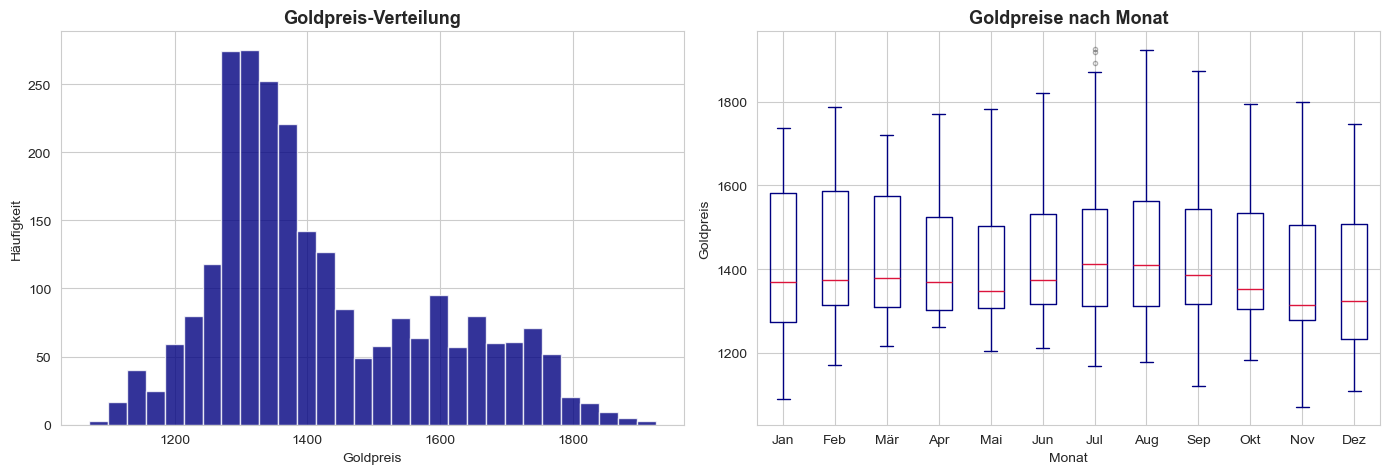

In [88]:
gold_daily = df_gold["Price"].resample("D").mean().to_frame()

gold_daily["month"] = gold_daily.index.month
gold_daily["year"] = gold_daily.index.year

month_map = {1: "Jan", 2: "Feb", 3: "Mär", 4: "Apr", 5: "Mai", 6: "Jun",
             7: "Jul", 8: "Aug", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Dez"}

gold_daily["month_name"] = pd.Categorical(
    gold_daily["month"].map(month_map),
    categories=list(month_map.values()),
    ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm – Verteilung der Goldpreise
axes[0].hist(gold_daily["Price"].dropna(), bins=30, color="navy", alpha=0.8)
axes[0].set_title("Goldpreis-Verteilung", fontsize=13, weight="bold")
axes[0].set_xlabel("Goldpreis")
axes[0].set_ylabel("Häufigkeit")

# Boxplot pro Monat
gold_daily.boxplot(
    column="Price",
    by="month_name",
    ax=axes[1],
    boxprops=dict(color="navy"),
    medianprops=dict(color="crimson"),
    whiskerprops=dict(color="navy"),
    capprops=dict(color="navy"),
    flierprops=dict(marker="o", color="navy", alpha=0.3, markersize=3)
)

axes[1].set_title("Goldpreise nach Monat", fontsize=13, weight="bold")
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Goldpreis")

fig.suptitle("")

plt.tight_layout()
plt.show()

## Erkenntnisse

**Goldpreis-Verteilung:** Die Goldpreise liegen überwiegend zwischen etwa 1.250 und 1.500. Höhere Preise über 1.700 treten seltener auf und stammen hauptsächlich aus den Jahren 2019–2020 mit stark steigenden Goldpreisen.

**Goldpreise nach Monat:** Die monatlichen Boxplots zeigen keine klare Saisonalität. Die Medianwerte bleiben über die Monate relativ ähnlich, allerdings ist in einigen Monaten eine höhere Streuung sichtbar. Die Unterschiede werden eher durch langfristige Marktbewegungen als durch saisonale Effekte verursacht.

## Gold Price – Tägliche Wachstumsrate

Die Wachstumsrate beschreibt die relative tägliche Veränderung des Goldpreises. Stationäre Schwankungen um 0 sind eine wichtige Voraussetzung für ARMA- und ARIMA-Modelle.

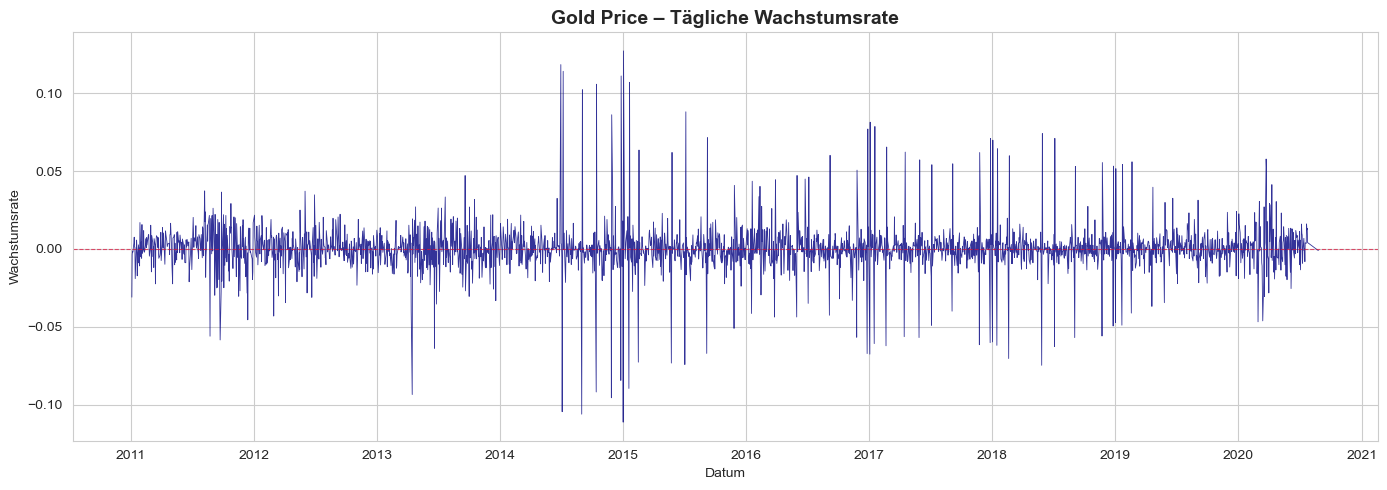

In [89]:
fig, ax = plt.subplots()

ax.plot(gold_growth.index, gold_growth.values, color="navy", linewidth=0.6, alpha=0.8)

ax.axhline(0, color="crimson", linewidth=0.8, linestyle="--", alpha=0.7)

ax.set_title(
    "Gold Price – Tägliche Wachstumsrate",
    fontsize=14,
    weight="bold"
)

ax.set_ylabel("Wachstumsrate")
ax.set_xlabel("Datum")

plt.tight_layout()
plt.show()

## Erkenntnisse – Tägliche Wachstumsrate

Die täglichen Wachstumsraten des Goldpreises schwanken überwiegend stationär um 0. Die meisten täglichen Änderungen sind relativ klein, einzelne starke Ausschläge markieren jedoch Phasen erhöhter Marktunsicherheit und Volatilität.

Besonders zwischen 2014 und 2019 treten stärkere positive und negative Schwankungen auf. Ein langfristiger Trend ist in der Wachstumsrate nicht mehr erkennbar, was darauf hindeutet, dass die transformierte Reihe näherungsweise stationär ist und sich damit besser für ARMA- oder ARIMA-Modelle eignet.

## Gold Price – Autokorrelationen (ACF)

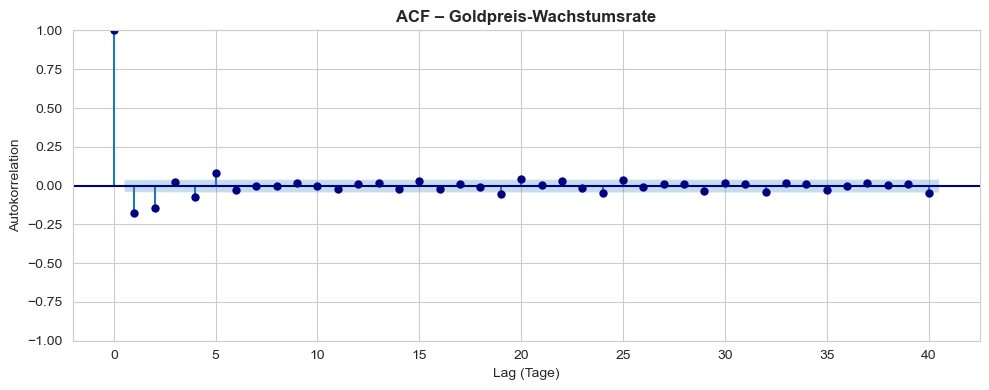

In [90]:
fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(gold_growth.dropna(), lags=40, ax=ax, alpha=0.05, color="navy")

ax.set_title( "ACF – Goldpreis-Wachstumsrate", fontsize=12, weight="bold")

ax.set_xlabel("Lag (Tage)")
ax.set_ylabel("Autokorrelation")

plt.tight_layout()
plt.show()

## Erkenntnisse – Autokorrelationen (ACF)

Die ACF der Goldpreis-Wachstumsrate zeigt nur schwache zeitliche Abhängigkeiten. Bereits nach den ersten Lags liegen die meisten Werte nahe 0 und innerhalb des Konfidenzintervalls.

Lediglich bei den ersten Lags ist eine leichte negative Autokorrelation erkennbar. Das deutet darauf hin, dass auf kurzfristige Preissteigerungen häufig kleine Gegenbewegungen folgen. Insgesamt wirkt die Wachstumsrate jedoch weitgehend zufällig und besitzt nur geringe Vorhersagbarkeit.

## Apple

In [91]:
# APPLE → täglicher Schlusskurs
apple_daily = df_apple["Close"].resample("D").mean().to_frame()

# ── 1. Basisstatistik ────────────────────────────────────────────────────────
print("Statistik:")
print(apple_daily.describe())

print("\nZeitraum:")
print(apple_daily.index.min(), "→", apple_daily.index.max())

print("\nNaN Werte (Wochenenden / Feiertage):")
print(apple_daily.isnull().sum())


Statistik:
             Close
count  2595.000000
mean    118.868833
std      76.576106
min      20.584814
25%      41.941475
50%     124.005119
75%     175.786880
max     285.922455

Zeitraum:
2016-01-05 00:00:00 → 2026-04-30 00:00:00

NaN Werte (Wochenenden / Feiertage):
Close    1174
dtype: int64


Der durchschnittliche tägliche Schlusskurs von Apple liegt bei rund 118,83 USD, mit einer Standardabweichung von etwa 56 USD — ein Zeichen für den erheblichen Kursanstieg über den Beobachtungszeitraum. Fehlende Werte entstehen systembedingt an Wochenenden und Feiertagen.

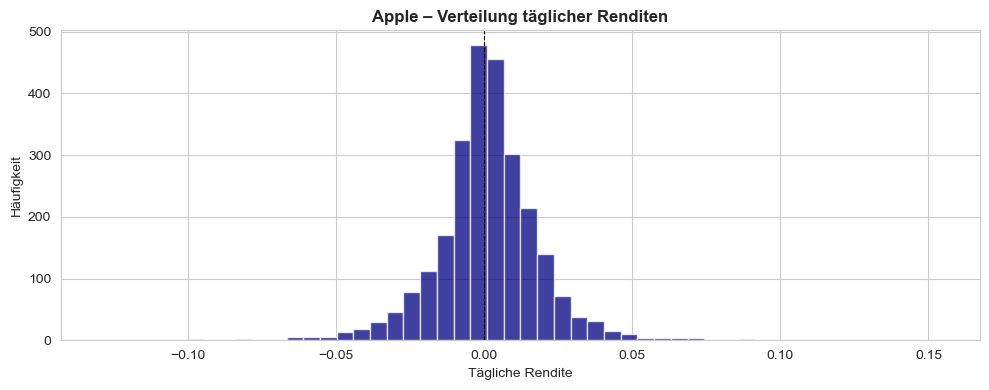

In [92]:

# ── 2. Verteilung täglicher Renditen ─────────────────────────────────────────
apple_returns = apple_daily["Close"].dropna().pct_change().dropna()

plt.figure(figsize=(10, 4))
plt.hist(apple_returns, bins=50, color="navy", alpha=0.75)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Apple – Verteilung täglicher Renditen", fontsize=12, weight="bold")
plt.xlabel("Tägliche Rendite")
plt.ylabel("Häufigkeit")
plt.tight_layout()
plt.show()


**Rendite-Verteilung:** Die täglichen Renditen sind eng um die Null konzentriert, mit vereinzelten Ausreißern in beide Richtungen. Dies ist typisch für Aktienkurse und deutet auf Leptokurtosis (fette Tails) hin.

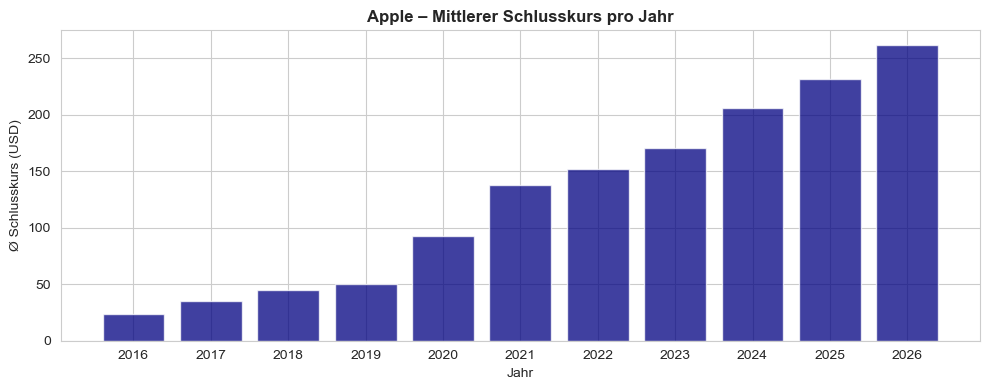

In [93]:
# ── 3. Jahresvergleich (mittlerer Schlusskurs pro Jahr) ──────────────────────
yearly_mean = apple_daily["Close"].groupby(apple_daily.index.year).mean()

plt.figure(figsize=(10, 4))
plt.bar(yearly_mean.index.astype(str), yearly_mean.values, color="navy", alpha=0.75)
plt.title("Apple – Mittlerer Schlusskurs pro Jahr", fontsize=12, weight="bold")
plt.xlabel("Jahr")
plt.ylabel("Ø Schlusskurs (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Jahresvergleich:** Der mittlere Schlusskurs steigt von 2016 bis 2024 kontinuierlich an, mit einem besonders starken Sprung zwischen 2019 und 2020.

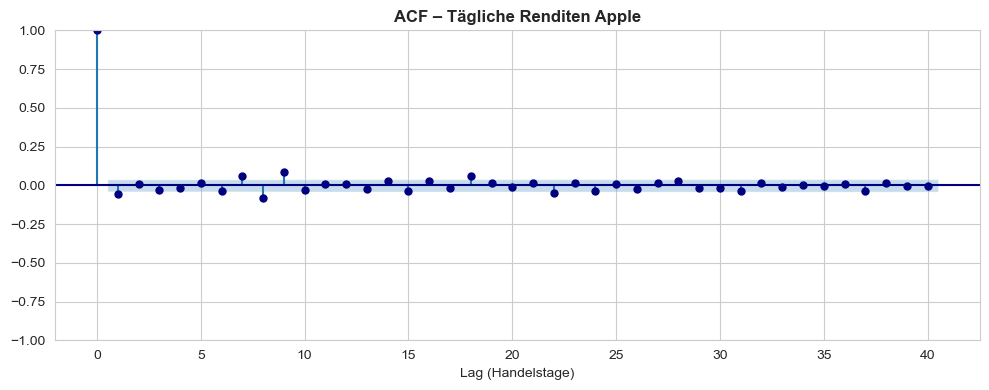

In [94]:
# ── 4. ACF der täglichen Renditen ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(apple_returns.dropna(), lags=40, ax=ax, alpha=0.05, color="navy")
ax.set_title("ACF – Tägliche Renditen Apple", fontsize=12, weight="bold")
ax.set_xlabel("Lag (Handelstage)")
plt.tight_layout()
plt.show()

**ACF der Renditen:** Die Autokorrelationen liegen nahezu vollständig im Konfidenzintervall — die Renditen sind weitgehend unkorreliert und damit schwer vorhersagbar, was konsistent mit der Efficient Market Hypothesis ist.

## Weather

Verteilung, saisonale Streuung und tägliche Temperaturdifferenzen als Grundlage
für die anschließende Zeitreihenanalyse.

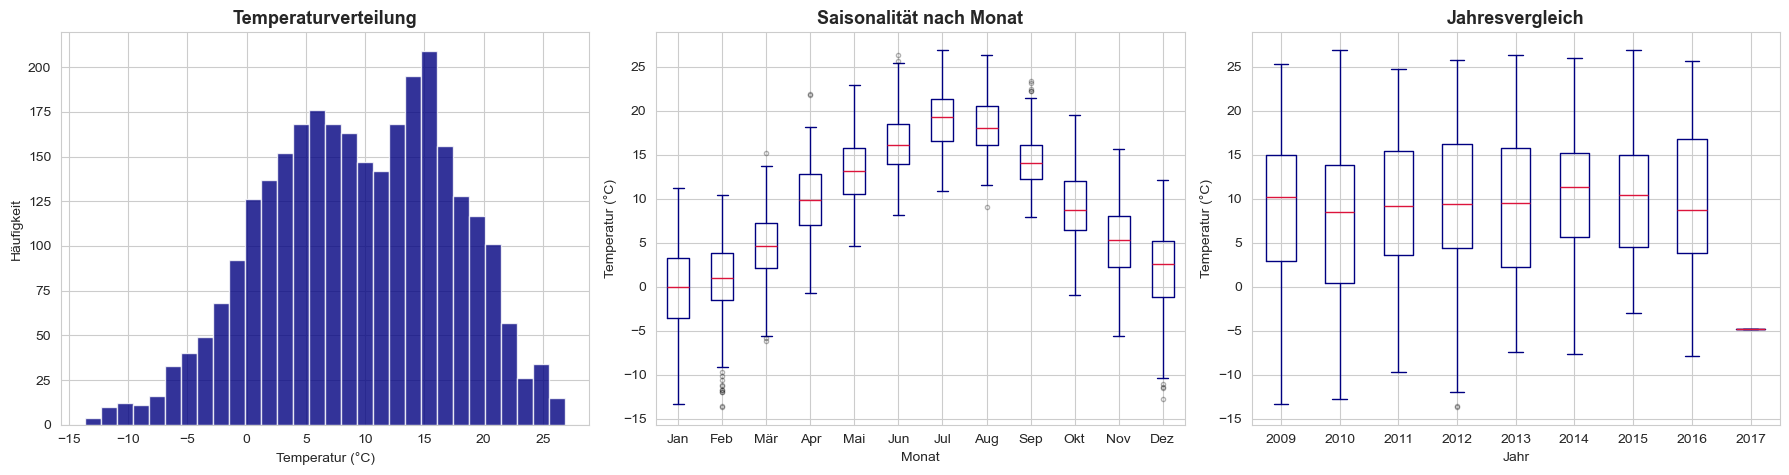

In [95]:
weather_daily = df_weather["T (degC)"].resample("D").mean().to_frame()
weather_daily["month"] = weather_daily.index.month
weather_daily["year"] = weather_daily.index.year

month_map = {1: "Jan", 2: "Feb", 3: "Mär", 4: "Apr", 5: "Mai", 6: "Jun",
             7: "Jul", 8: "Aug", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Dez"}
weather_daily["month_name"] = pd.Categorical(
    weather_daily["month"].map(month_map),
    categories=list(month_map.values()),
    ordered=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramm – Gesamtverteilung der Tagestemperaturen
axes[0].hist(weather_daily["T (degC)"].dropna(), bins=30, color="navy", alpha=0.8)
axes[0].set_title("Temperaturverteilung", fontsize=13, weight="bold")
axes[0].set_xlabel("Temperatur (°C)")
axes[0].set_ylabel("Häufigkeit")

# Boxplot pro Monat – saisonale Streuung
weather_daily.boxplot(column="T (degC)", by="month_name", ax=axes[1],
                      boxprops=dict(color="navy"),
                      medianprops=dict(color="crimson"),
                      whiskerprops=dict(color="navy"),
                      capprops=dict(color="navy"),
                      flierprops=dict(marker="o", color="navy", alpha=0.3, markersize=3))
axes[1].set_title("Saisonalität nach Monat", fontsize=13, weight="bold")
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Temperatur (°C)")
fig.suptitle("")

# Boxplot pro Jahr – jahresübergreifender Vergleich
weather_daily.boxplot(column="T (degC)", by="year", ax=axes[2],
                      boxprops=dict(color="navy"),
                      medianprops=dict(color="crimson"),
                      whiskerprops=dict(color="navy"),
                      capprops=dict(color="navy"),
                      flierprops=dict(marker="o", color="navy", alpha=0.3, markersize=3))
axes[2].set_title("Jahresvergleich", fontsize=13, weight="bold")
axes[2].set_xlabel("Jahr")
axes[2].set_ylabel("Temperatur (°C)")
fig.suptitle("")

plt.tight_layout()
plt.show()

## Erkenntnisse
**Temperaturverteilung:** Die Tagestemperaturen sind annähernd normalverteilt mit einem
leichten rechtsseitigen Schwerpunkt um ~15°C. Der Großteil der Werte liegt zwischen 0°C
und 20°C, Extremwerte reichen von –15°C bis +25°C.

**Saisonalität:** Die Monatsboxplots zeigen einen klaren saisonalen Zyklus. Die Wintermonate
Januar und Februar liegen im Median unter 0°C mit hoher Streuung, die Sommermonate Juli
und August erreichen Medianwerte um ~19°C. Die größte Streuung tritt in den
Übergangsmonaten März und Oktober auf.

**Jahresvergleich:** Die Mediantemperaturen sind über die Jahre 2009–2016 weitgehend stabil
(~8–10°C). Auffällig ist 2012 mit einem negativen Ausreißer (~–15°C), was mit dem im
Zeitreihenverlauf bereits identifizierten Kälteeinbruch übereinstimmt. 2017 ist aufgrund
unvollständiger Daten (nur Januar) nicht repräsentativ.

## Tägliche Temperaturdifferenz
Differenzenbildung (erste Differenz) nach $y_t = y_t - y_{t-1}$.
Stationäre Schwankungen um 0 deuten darauf hin, dass die differenzierte Reihe 
keine systematischen Trends aufweist.

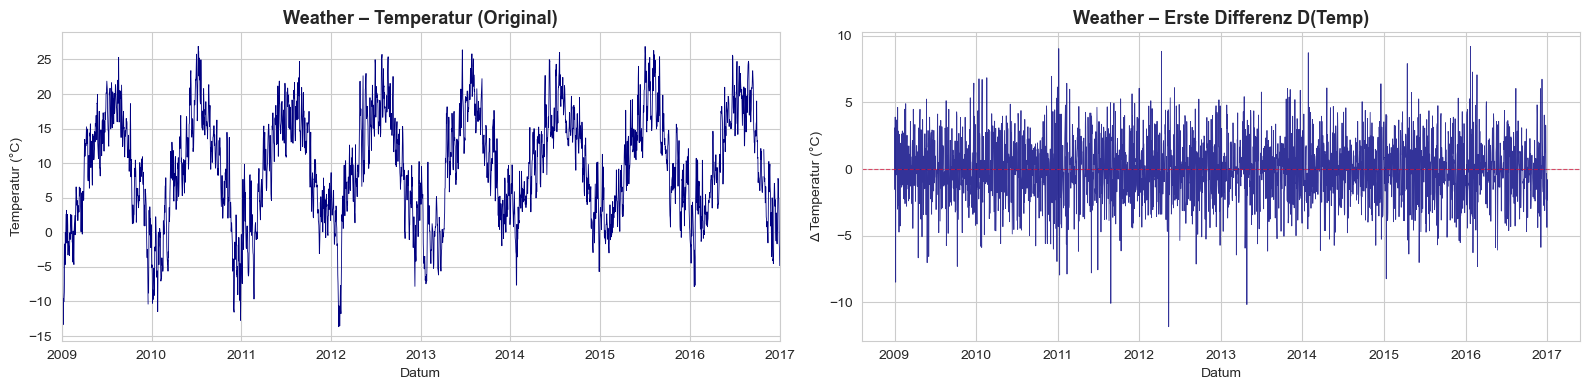

In [96]:
temp_diff = df_weather["T (degC)"].resample("D").mean().diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Original (nicht-differenziert)
df_weather["T (degC)"].resample("D").mean().plot(
    ax=axes[0], color="navy", linewidth=0.6
)
axes[0].set_title("Weather – Temperatur (Original)", fontsize=13, weight="bold")
axes[0].set_ylabel("Temperatur (°C)")
axes[0].set_xlabel("Datum")

# Erste Differenz
axes[1].plot(temp_diff.index, temp_diff.values, color="navy", linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color="crimson", linewidth=0.8, linestyle="--", alpha=0.7)
axes[1].set_title("Weather – Erste Differenz D(Temp)", fontsize=13, weight="bold")
axes[1].set_ylabel("Δ Temperatur (°C)")
axes[1].set_xlabel("Datum")

plt.tight_layout()
plt.show()

## Erkenntnisse – Tägliche Temperaturdifferenz

Die täglichen Temperaturdifferenzen schwanken stationär um 0°C mit einer typischen
Tagesänderung von ±2–3°C. Einzelne Ausreißer bis ±10°C markieren abrupte Wetterlagen.
Das Fehlen eines systematischen Trends oder einer Saisonalität in der differenzierten Reihe
bestätigt, dass die Differenzenbildung die Nichtstationarität der Rohdaten erfolgreich beseitigt —
eine zentrale Voraussetzung für die ARMA-Modellierung.

In [97]:
weather_series = df_weather["T (degC)"].resample("D").mean().dropna()

for label, series in [("Original", weather_series), ("Erste Differenz", weather_series.diff().dropna())]:
    res = adfuller(series, autolag="AIC")
    stat = "stationär" if res[1] < 0.05 else "nicht stationär"
    print(f"ADF {label}: Stat={res[0]:.9f}, p={res[1]:.4f} → {stat}")



ADF Original: Stat=-3.551486067, p=0.0068 → stationär
ADF Erste Differenz: Stat=-18.268943165, p=0.0000 → stationär


In [98]:
series = df_weather["T (degC)"].resample("D").mean().dropna()

adf_p = adfuller(series, autolag="AIC")[1]
kpss_p = kpss(series, regression="c", nlags="auto")[1]

print(f"ADF  p-Wert: {adf_p:.4f} → {'stationär' if adf_p < 0.05 else 'nicht stationär'}")
print(f"KPSS p-Wert: {kpss_p:.4f} → {'nicht stationär' if kpss_p < 0.05 else 'stationär'}")

ADF  p-Wert: 0.0068 → stationär
KPSS p-Wert: 0.1000 → stationär


/var/folders/s1/4yhj73sx3m5cfwgr45gzty_m0000gn/T/ipykernel_25257/3275610629.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression="c", nlags="auto")[1]


ADF nach Differenzierung: p = 0.0068 → stationär ✓


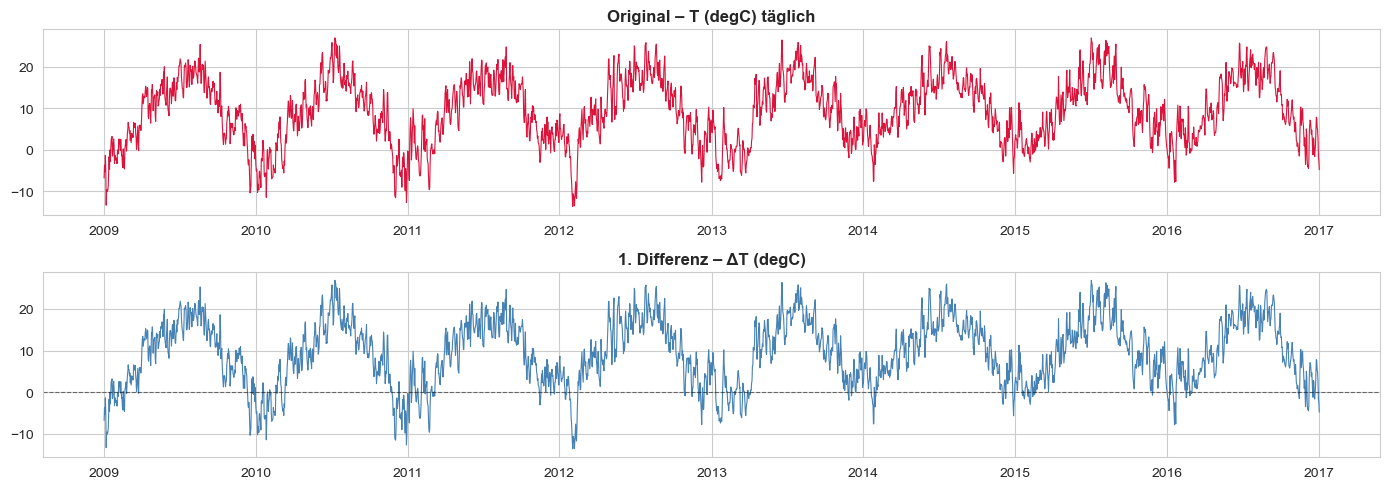

In [99]:
# series bereits täglich resampelt aus Block 1

series_diff = series

adf_p2 = adfuller(series_diff, autolag="AIC")[1]
print(f"ADF nach Differenzierung: p = {adf_p2:.4f} → {'stationär ✓' if adf_p2 < 0.05 else 'noch nicht stationär'}")

fig, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].plot(series.index, series, color="crimson", linewidth=0.8)
axes[0].set_title("Original – T (degC) täglich", weight="bold")
axes[1].plot(series_diff.index, series_diff, color="steelblue", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
axes[1].set_title("1. Differenz – ΔT (degC)", weight="bold")
plt.tight_layout()
plt.show()

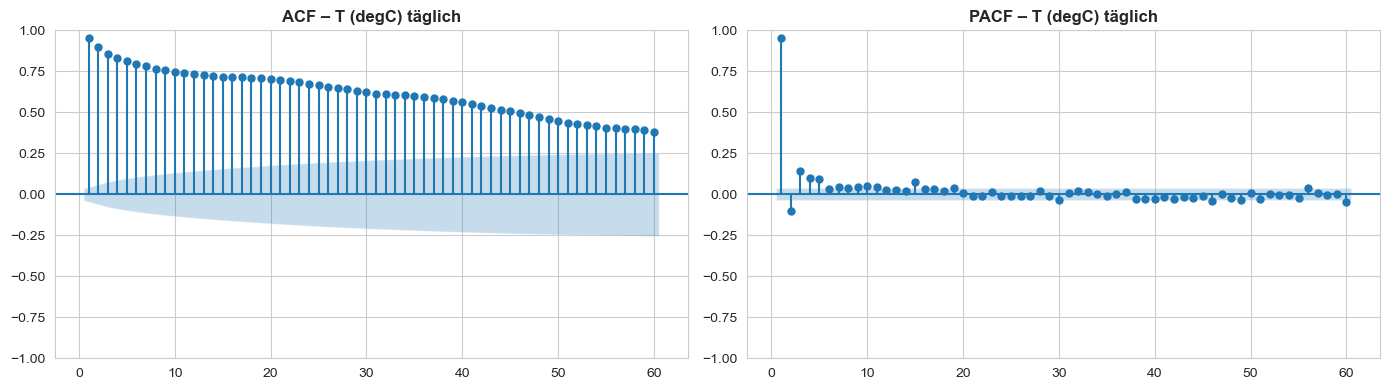

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series.values, lags=60, zero=False, ax=axes[0])
plot_pacf(series.values, lags=60, zero=False, method="ywm", ax=axes[1])
axes[0].set_title("ACF – T (degC) täglich", weight="bold")
axes[1].set_title("PACF – T (degC) täglich", weight="bold")
plt.tight_layout()
plt.show()

In [101]:
def AR1_fit_and_check(series, name):
    """
    Schätzt phi eines AR(1)-Modells und prüft ob die Zeitreihe stationär ist.
    y_t = phi · y_{t-1} + ε_t
    Stationär wenn |φ| < 1
    """
    y = series.values
    
    # phi schätzen: OLS -> einfach y[t] auf y[t-1] regressieren
    y_lag = y[:-1]   # y_{t-1}
    y_cur = y[1:]    # y_t
    
    # phi = Cov(y_t, y_{t-1}) / Var(y_{t-1})
    phi = np.cov(y_cur, y_lag)[0, 1] / np.var(y_lag)
    
    # Erwartungswert & Varianz (aus Vorlesung Folie 52)
    sigma2  = np.var(y_cur - phi * y_lag)
    E_y     = np.mean(y)
    gamma_0 = sigma2 / (1 - phi**2) if abs(phi) < 1 else float('inf')
    
    print(f'\n  {name}  ')
    print(f'Geschätztes phi        = {phi:.4f}')
    print(f'Erwartungswert E[y]  = {E_y:.4f}')
    print(f'Varianz y(0)         = {gamma_0:.4f}')
    
    return phi


# Auf alle 3 Datensätze anwenden
phi_amazon  = AR1_fit_and_check(df_amazon['quantity_sold'], 'Amazon Sales')
phi_apple   = AR1_fit_and_check(df_apple['Close'],          'Apple Stock')
phi_weather = AR1_fit_and_check(df_weather['T (degC)'],     'Weather Temperatur')


  Amazon Sales  
Geschätztes phi        = 0.0005
Erwartungswert E[y]  = 2.9689
Varianz y(0)         = 1.9719

  Apple Stock  
Geschätztes phi        = 1.0003
Erwartungswert E[y]  = 118.8688
Varianz y(0)         = inf

  Weather Temperatur  
Geschätztes phi        = 0.9996
Erwartungswert E[y]  = 9.4947
Varianz y(0)         = 68.7417
